In [1]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import os
import logging
import h5py
import matplotlib.pyplot as plt  # type: ignore
import numpy as np
import healpy as hp
from itertools import product

from mlpng.utils import *
from mlpng.generator import Generator
from mlpng.utils.utils import *
from mlpng.utils.plots import plot_cl, plot_map, plot_map_alm

import lenspyx
from lenspyx import utils_hp
import matplotlib.ticker as ticker

from joblib import Parallel, delayed
from scipy.interpolate import interp1d
from ksw.radial_functional import radial_func

from mlpng.bispectrum import (
    compute_bispectrum,
    # compute_trispectrum,
)
import vegas

from tqdm.auto import tqdm

In [3]:
# generator = Generator(
#     [
#         "settings/n128.json",
#         "--nsims",
#         "1",
#         "--pols",
#         "T",
#         "--phi_scale",
#         "2.0",
#         "--shape",
#         "local",
#         "--no-noise",
#         # "--double_precision",
#     ]
# )

# Get the unlensed gaussian Alms

This should be correct, notice we do not do any non-gaussian here due to just testing the lensing deflection field.

In [4]:
# pol_idxs = generator.pol_idxs()

# sims = [
#     hp.synalm(generator.c_ell, lmax=generator.lmax, new=True)
#     for _ in range(generator.nsims)
# ]
# sims = remove_mono_dipole(np.array(sims))
# alm_l = np.ascontiguousarray(sims)[0, 0]  # ensure contiguous memory

# plot_cl_alm(
#     generator,
#     alm_l,
#     title=r"Unlensed gaussian $C_{\ell}^{TT}$",
#     ylabel=r"$C_{\ell}^{TT}$",
#     show=True,
#     plot_camb=True,
# )
# plot_map_alm(
#     generator,
#     alm_l,
#     title=r"Unlensed gaussian $C_{\ell}^{TT}$",
#     zoom=True,
#     show=True,
# )

# Deflection Fields

Here we generate the deflection fields $d_{\ell m}$ for the lensing. We get the lensing potential power spectrum $C_{\ell}^{\phi\phi}$ from CAMB, and convert this to the deflection field by $d_{\ell m} = \sqrt{\ell(\ell+1)}C_{\ell}^{\phi\phi}$. This is per the lenspyx demo https://github.com/carronj/lenspyx/blob/master/examples/demo_lenspyx.ipynb , but I would appricate confirmation that the $C_{\ell}^{\phi\phi}$ is the correct one to use here.

To scale the lensing potential I am currently applying the scale to the $p_{lm}$ before converting to the harmoincs. This is disable right now as I am testing just a normal lensing potential, but does that look correct?

In [5]:
# # we use a buffer for the lmax to ensure we can compute the lensing potential without error
# lmax = generator.lmax + generator.lmax_buffer

# # our conversion factor = sqrt(l * (l + 1))
# fl = np.sqrt(np.arange(lmax + 1) * np.arange(1, lmax + 2))

# # cl_phi is PP PT PE, we only want the phi phi part
# cl_phi = generator.cosmo._camb_data.get_lens_potential_cls(
#     lmax,
#     "muK",
#     raw_cl=True,
# )
# cl_phi = cl_phi[..., 0]

# # the weird factors here are to match plots from lewis
# # https://indico.cern.ch/event/218615/contributions/448794/attachments/353290/492159/Lewis.pdf page 11
# plot_cl(
#     generator,
#     cl_phi * fl**4 / 2 / np.pi,
#     title=r"Lensing potential $C_{\ell}^{\phi\phi}$",
#     ylabel=r"$(\ell (\ell + 1))^2 / 2 \pi\;C_{\ell}^{\phi\phi}$",
#     show=True,
#     scale=False,
#     plot_func=plt.loglog,
# )


In [6]:
# alm_phi = hp.synalm(
#     cl_phi,
#     lmax,
#     lmax,
#     new=True,
#     verbose=False,
# )
# alm_phi *= generator.phi_scale  # scale the lensing potential by phi_scale

# plot_cl_alm(
#     generator,
#     alm_phi,
#     title="Lensing potential alm, $\phi_{lm}$",
#     ylabel=r"$\phi_{lm}$",
#     show=True,
#     # scale=False,
#     plot_func=plt.loglog,
# )
# plot_map_alm(generator, alm_phi, title="plm", zoom=True, show=True)


In [7]:
# # transform the lensing potential into spin-1 deflection field
# dlm = hp.almxfl(alm_phi, fl)

# plot_cl_alm(
#     generator,
#     dlm,
#     lmax=lmax,
#     title="Lensing deflection field alm",
#     ylabel=r"$d_{lm}$",
#     # scale=False
#     show=True,
#     plot_func=plt.loglog,
# )
# plot_map_alm(generator, dlm, title="$d_{lm}$", zoom=True, show=True)

here we get the lensed maps from the gaussian alm's using our $d_{lm}$s calculated previously. We only do a single T mode lenmap no matter the settings above for testing, this gives us the `alm_l[0, 0]` below which is dimensions `(sim, pol, data)`.

In [8]:
# lenmap = lenspyx.alm2lenmap(
#     alm_l,
#     dlm,
#     geometry=("healpix", {"nside": generator.nside}),
#     nthreads=generator.slurm.n_cpus,
# )
# lenmap = remove_mono_dipole(lenmap)

# plot_map(lenmap, title="Lensed map", zoom=True, show=True)

In [9]:
# unlen_map = hp.alm2map(
#     alm_l,
#     nside=generator.nside,
#     lmax=generator.lmax,
#     verbose=False,
# )
# unlen_map = remove_mono_dipole(unlen_map)

# plot_map(unlen_map, title="Unlensed map", zoom=True, show=True)
# plot_map(lenmap - unlen_map, title="Lensed - Unlensed map", zoom=True, show=True)

Here is where we caculate the error in our estimator for the lenses code. To get the $C_{\ell}$ used to get the $\text{icov}=C^{-1}$ used in the calculation I am using the lensed maps and using anafast to calculate the cls. With many maps I would average over the resulting cls. The issues here is a higher lensing potential will result in a lower variance which is not what we expect.

In [10]:
# cl_lens = hp.anafast(lenmap, use_pixel_weights=True)
# cl_lens[:2] = 0

# plot_cl(generator, cl_lens, title="Lensed C_l", show=True, plot_camb=True)

# plot_cl_vs(
#     generator,
#     generator.c_ell[0],
#     cl_lens,
#     title="Lensed vs Unlensed C_l",
#     ylabel=r"$C_{\ell}^{TT}$",
#     show=True,
#     # scale=False,
#     # plot_func=plt.plot,
# )

# plot_cl(
#     generator,
#     cl_lens / generator.c_ell,
#     title="Lensed C_l / Unlensed C_l",
#     ylabel=r"$\frac{C_{\ell}^{TT}}{C_{\ell}^{TT,unlensed}}$",
#     show=True,
#     scale=False,
#     plot_func=plt.plot,
# )

# plot_cl(
#     generator,
#     (cl_lens - generator.c_ell) / generator.c_ell,
#     title="(Lensed - Unlensed C_l) / Unlensed C_l",
#     ylabel=r"$\frac{C_{\ell}^{TT} - C_{\ell}^{TT,unlensed}}{C_{\ell}^{TT,unlensed}}$",
#     show=True,
#     scale=False,
#     plot_func=plt.plot,
# )

# Compute the fishers

Here we compute the fishers, this takes a very long time based on the nside used

In [11]:
# fisher_mat = np.array(generator.compute_fisher_shapes(generator.shapes))
# if len(generator.shapes) > 1:
#     marg_likes = np.sqrt(np.diag(np.linalg.inv(fisher_mat)))
# else:
#     marg_likes = np.sqrt(1 / fisher_mat)

# print(f"Unlensed marginal likelihoods: {marg_likes}")

In [12]:
# lens_cls = generator.cosmo.c_ell["lensed_scalar"]["c_ell"][: generator.nell, 0]
# lens_cls *= generator.phi_scale

# plot_cl_vs(generator, lens_cls, cl_lens, labels=["camb", "lens"], show=True)

In [13]:
# icov = 1 / lens_cls
# icov[: generator.lmin] = 0.0
# icov = np.array(icov)

# fisher_mat = generator.compute_fisher_shapes(generator.shapes, icov=icov)
# if len(generator.shapes) > 1:
#     marg_likes_lens = np.sqrt(np.diag(np.linalg.inv(fisher_mat)))
# else:
#     marg_likes_lens = np.sqrt(1 / fisher_mat)

# print(f"Marginal likelihoods: {marg_likes_lens}")
# print(f"diff: {marg_likes_lens - marg_likes}")

In [14]:
# diff = marg_likes_lens - marg_likes
# ratio = marg_likes_lens / marg_likes

# print("nside:", generator.nside)
# print(
#     f"| {generator.phi_scale} | {float(marg_likes)} | {float(marg_likes_lens)} | {float(diff)} | {float(ratio)} |"
# )

# the big loop

Just do a big loop to get a table, will take a long time

In [15]:
# # disable a root logger error from CAMB
# logging.getLogger("root").setLevel(logging.ERROR)

# for phi in [1.0, 1.1, 2, 3, 5, 10, 30, 100]:
#     generator = Generator(
#         [
#             "settings/n64.json",
#             "--nsims",
#             "1",
#             "--pols",
#             "T",
#             "--phi_scale",
#             str(phi),
#             "--shape",
#             "local",
#             "--no-noise",
#             # "--double_precision",
#         ],
#         logging.ERROR,
#     )

#     pol_idxs = generator.pol_idxs()

#     sims = [
#         hp.synalm(generator.c_ell, lmax=generator.lmax, new=True)
#         for _ in range(generator.nsims)
#     ]
#     sims = remove_mono_dipole(np.array(sims))
#     alm_l = np.ascontiguousarray(sims)[0, 0]  # ensure contiguous memory

#     # we use a buffer for the lmax to ensure we can compute the lensing potential without error
#     lmax = generator.lmax + generator.lmax_buffer

#     # our conversion factor = sqrt(l * (l + 1))
#     fl = np.sqrt(np.arange(lmax + 1) * np.arange(1, lmax + 2))

#     # cl_phi is PP PT PE, we only want the phi phi part
#     cl_phi = generator.cosmo._camb_data.get_lens_potential_cls(
#         lmax,
#         "muK",
#         raw_cl=True,
#     )
#     cl_phi = cl_phi[..., 0]

#     alm_phi = hp.synalm(
#         cl_phi,
#         lmax,
#         lmax,
#         new=True,
#         verbose=False,
#     )
#     alm_phi *= generator.phi_scale  # scale the lensing potential by phi_scale

#     dlm = hp.almxfl(alm_phi, fl)

#     lenmap = lenspyx.alm2lenmap(
#         alm_l,
#         dlm,
#         geometry=("healpix", {"nside": generator.nside}),
#         nthreads=generator.slurm.n_cpus,
#     )
#     lenmap = remove_mono_dipole(lenmap)

#     lens_cls = generator.cosmo.c_ell["lensed_scalar"]["c_ell"][: generator.nell, 0]
#     # lens_cls *= generator.phi_scale

#     icov = 1 / lens_cls
#     icov[: generator.lmin] = 0.0
#     icov = np.array(icov)

#     fisher_mat = np.array(generator.compute_fisher_shapes(generator.shapes))
#     if len(generator.shapes) > 1:
#         marg_likes = np.sqrt(np.diag(np.linalg.inv(fisher_mat)))
#     else:
#         marg_likes = np.sqrt(1 / fisher_mat)

#     fisher_mat = generator.compute_fisher_shapes(generator.shapes, icov=icov)
#     if len(generator.shapes) > 1:
#         marg_likes_lens = np.sqrt(np.diag(np.linalg.inv(fisher_mat)))
#     else:
#         marg_likes_lens = np.sqrt(1 / fisher_mat)

#     diff = marg_likes_lens - marg_likes
#     ratio = marg_likes_lens / marg_likes

#     print(
#         f"| {generator.phi_scale} | {float(marg_likes)} | {float(marg_likes_lens)} | {float(diff)} | {float(ratio)} |"
#     )


# S/N test

We will determine the effects of gravitational lensing by calculating the reduction in the
estimator signal to noise when the weights derived by ignoring gravitational lensing are used.
This means that the weight defined in Eq. (25, W(l_1, l_2, l_3)) will always be evaluated using unlensed CMB
power spectra.

however the Gaussian and non-Gaussian six-point functions in Eqs. (24, <N^2>),
(28, delta<N^2>) will be evaluated with the lensed CMB power spectra when specified

In [16]:
generator = Generator(
    [
        "settings/babich.json",
        "--nsims",
        "1",
        "--pols",
        "T",
        # "--no-noise",
        # "--phi_scale",
        # "2.0",
        "--shape",
        "local",
        # "--lmax",
        # "2500",
    ]
)

c_ell = generator.c_ell[0]
c_ell_lens = generator.c_ell_lens[0]
LMAX = generator.lmax // 2

cov = generator.cov[0]
cov_lens = generator.cov_lens[0]

cl_phi = generator.cl_phi

14-Aug-25 15:02:56 - mlpng.core - DEBUG - Parsing CLI args: ['settings/babich.json', '--nsims', '1', '--pols', 'T', '--shape', 'local']
14-Aug-25 15:02:56 - mlpng.core - INFO - Loading settings from file 'settings/babich.json'
14-Aug-25 15:02:56 - mlpng.core - DEBUG - Forcing setting 'nsims' to 1 due to CLI
14-Aug-25 15:02:56 - mlpng.core - DEBUG - Forcing setting 'pols' to T due to CLI
14-Aug-25 15:02:56 - mlpng.core - DEBUG - Forcing setting 'shapes' to ['local'] due to CLI
14-Aug-25 15:02:56 - mlpng.core - DEBUG - Overriding cosmo param 'As' from 2.13e-09 to 2.448e-09
14-Aug-25 15:02:56 - mlpng.core - DEBUG - Overriding cosmo param 'ns' from 0.9624 to 1.0
14-Aug-25 15:02:56 - mlpng.core - DEBUG - Running with settings: 
{
  "cosmo_params": {
    "As": 2.448e-09,
    "ns": 1.0,
    "pivot_scalar": 0.05,
    "tau": 0.17,
    "ombh2": 0.0228096,
    "omch2": 0.1171584,
    "H0": 72.0
  },
  "nsims": 1,
  "nside": 1024,
  "pols": "T",
  "shapes": [
    "local"
  ]
}
14-Aug-25 15:02:56 -

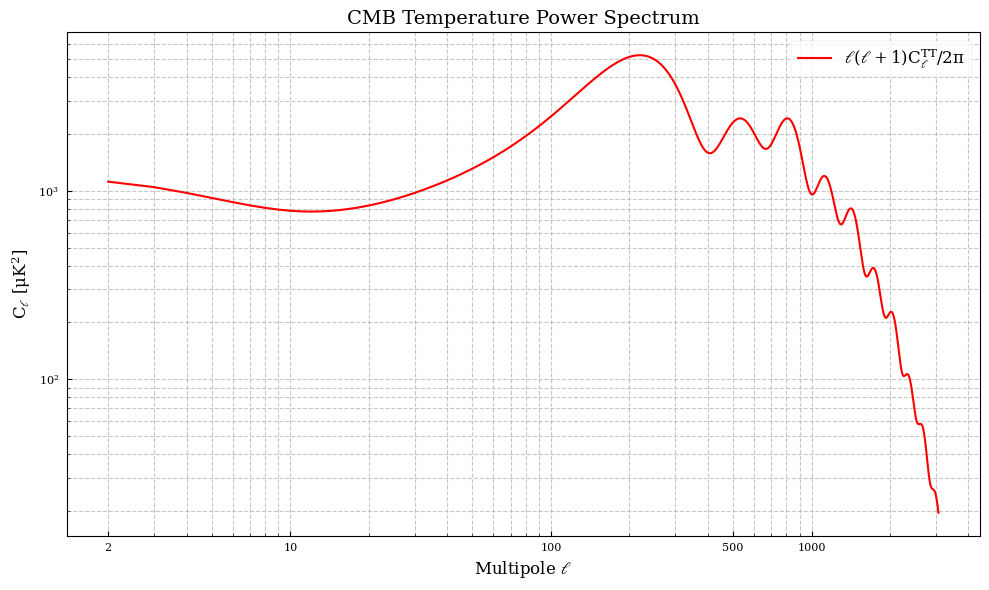

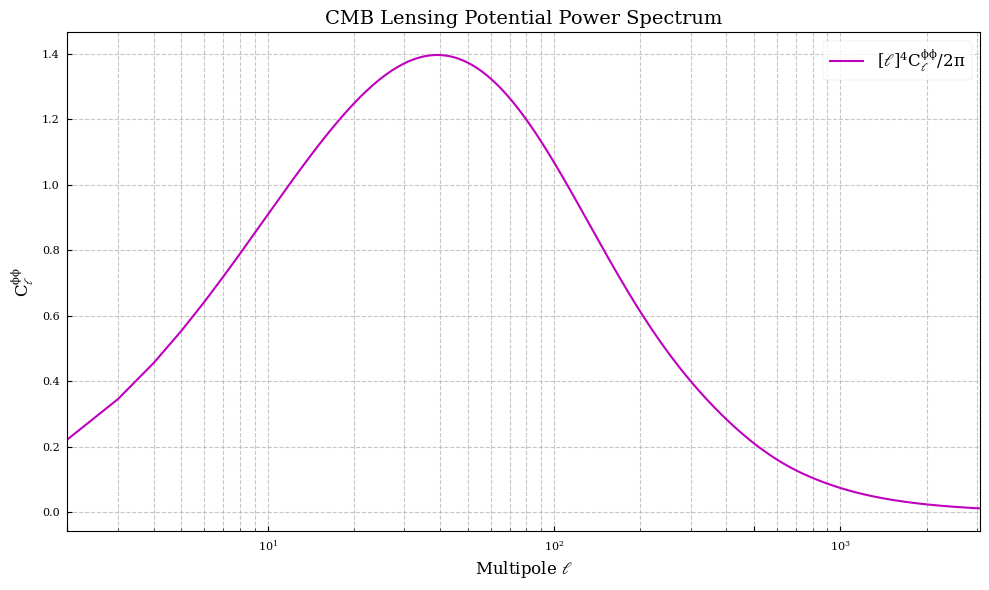

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))

scaled_c_ell = np.array(
    [ell * (ell + 1) * c_ell[ell] / (2 * np.pi) for ell in range(2, len(c_ell))]
)
ax.loglog(
    range(2, len(c_ell)),
    scaled_c_ell,
    "r-",
    lw=1.5,
    label=r"$\ell(\ell+1)C_{\ell}^{TT}/2\pi$",
)

# Formatting
ax.set_xlabel(r"Multipole $\ell$", fontsize=12)
ax.set_ylabel(r"$C_{\ell}$ [$\mu$K$^2$]", fontsize=12)
ax.set_title("CMB Temperature Power Spectrum", fontsize=14)
ax.grid(which="both", linestyle="--", alpha=0.7)
ax.legend(fontsize=12)

# Adjust x-axis ticks to be more readable
ax.set_xticks([2, 10, 100, 500, 1000])
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(10, 6))

# Plot lensing potential with log-y scaling
ells = np.arange(len(cl_phi))
# ax.semilogy(ells, cl_phi, "g-", lw=1.5, label=r"Lensing potential $C_\ell^{\phi\phi}$")

# Also plot with (ℓ(ℓ+1))²/2π scaling which is often used for lensing potential
fl = (ells * (ells)) ** 2
scaled_cl_phi = cl_phi * fl / (2 * np.pi) * 10**7
ax.semilogx(
    ells[2:],
    scaled_cl_phi[2:],
    "m-",
    lw=1.5,
    label=r"$[\ell]^4 C_\ell^{\phi\phi}/2\pi$",
)
# Formatting
ax.set_xlabel(r"Multipole $\ell$", fontsize=12)
ax.set_ylabel(r"$C_\ell^{\phi\phi}$", fontsize=12)
ax.set_title("CMB Lensing Potential Power Spectrum", fontsize=14)
ax.grid(which="both", linestyle="--", alpha=0.7)
ax.legend(fontsize=12)

# Set x-axis range to start from ℓ=2
ax.set_xlim(2, len(cl_phi) - 1)

# Adjust x-axis ticks to be more readable
ax.set_xticks([2, 10, 100, 500, 1000])
# ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

plt.tight_layout()
plt.show()


In [18]:
# # b^local_l1l2l3 = 2 int dr r^2 a_l1(r) b_l2(r) b_l3(r) + perms

pol_idxs = generator.pol_idxs()
transfer = generator.cosmo.transfer

# get the transfer functions with tr_ell_k being \Delta_\ell(k)
tr_ells = transfer["ells"]
tr_k = transfer["k"]
tr_ell_k = transfer["tr_ell_k"]  # this is T, E, PHI
tr_ell_k = tr_ell_k[..., pol_idxs]

# camb returns transfers in zeta, need to convert to phi
tr_ell_k *= 5 / 3

# this will be the f(k) value to be placed in the radial function
# first will be for alpha_ell, second will be beta_ell
# see komatsu 2003 eq 5 and 6
f_k = np.ones((len(tr_k), 2), dtype=generator.r_dtype)

# we need to multiply the f_k by the delta_phi term, and convert from k^2 to k^-1
# see creminelii 2006, eq 16
# for delta_phi = A: (taken from adri's ksw)
# Planck defines A as <phi_k1 phi_k2> = (2pi)^3 delta(k12) A / k^3.
# CAMB defines As as <zeta_k2 zeta_k2> = (2pi)^3 delta(k12) 2 * pi^2 As / k^3.
# So A = (3/5)^2 * 2 * pi^2 As.
Pk = generator.cosmo.camb_params.primordial_power(tr_k, 0)
delta_phi = 2 * np.pi**2 * Pk * (3 / 5) ** 2
f_k[:, 1] = delta_phi * tr_k ** (-3)
rad = radial_func(f_k, tr_ell_k, tr_k, generator.radii, tr_ells)

alpha_ell = rad[..., 0]
alpha_l = interp1d(
    tr_ells,
    alpha_ell,
    "cubic",
    1,
    bounds_error=False,
    fill_value=0,
)(generator.ells)[..., 0]

beta_ell = rad[..., 1]
beta_l = interp1d(
    tr_ells,
    beta_ell,
    "cubic",
    1,
    bounds_error=False,
    fill_value=0,
)(generator.ells)[..., 0]


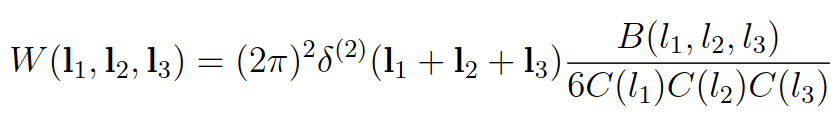

In [19]:
def compute_W(l1, l2, l3):
    c_ell = generator.c_ell[0]
    C6 = 6 * c_ell[l1] * c_ell[l2] * c_ell[l3]
    B = compute_bispectrum(alpha_l.T, beta_l.T, l1, l2, l3, generator.radii)
    return (2 * np.pi) ** 2 * B / C6


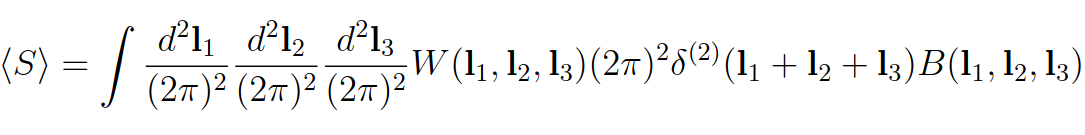

In [20]:
class SIntegrand:
    def __init__(self, lmax, alpha, beta, rs):
        self.lmax = lmax
        self.alpha = alpha
        self.beta = beta
        self.rs = rs

    def __call__(self, x):
        l1 = np.array([x[0], x[1]])
        l2 = np.array([x[2], x[3]])

        # delta(l1+l2+l3) from the W
        l3 = -l1 - l2

        # get the magnitudes as ints so we get an index close
        l1_mag = int(round(np.sqrt(l1.dot(l1))))
        l2_mag = int(round(np.sqrt(l2.dot(l2))))
        l3_mag = int(round(np.sqrt(l3.dot(l3))))

        for x in [l1_mag, l2_mag, l3_mag]:
            if not 2 <= x <= self.lmax:
                return 0.0

        W = compute_W(l1_mag, l2_mag, l3_mag)
        B = compute_bispectrum(self.alpha, self.beta, l1_mag, l2_mag, l3_mag, self.rs)
        return W * B


def compute_S(lmax=LMAX, neval=3e5, summary=False):
    integrand = SIntegrand(lmax, alpha_l.T, beta_l.T, generator.radii)
    integ = vegas.Integrator([[-lmax, lmax], [-lmax, lmax]] * 2)

    integ(
        integrand,
        nitn=10,
        neval=neval // 10,
        nproc=generator.slurm.n_cpus,
    )
    result = integ(
        integrand,
        nitn=10,
        neval=neval,
        nproc=generator.slurm.n_cpus,
    )

    if summary:
        print(result.summary(), flush=True)

    return result.mean / (2 * np.pi) ** 4 / np.pi


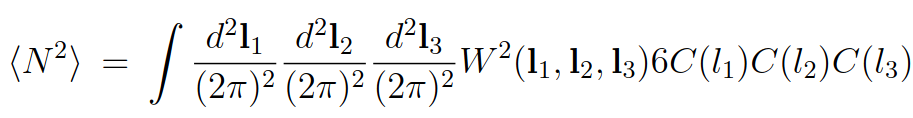

In [21]:
class N2Integrand:
    def __init__(self, lmax, c_ell):
        self.lmax = lmax
        self.c_ell = c_ell

    def __call__(self, x):
        l1 = np.array([x[0], x[1]])
        l2 = np.array([x[2], x[3]])

        # delta(l1+l2+l3) from the W
        l3 = -l1 - l2

        l1_mag = int(round(np.sqrt(l1.dot(l1))))
        l2_mag = int(round(np.sqrt(l2.dot(l2))))
        l3_mag = int(round(np.sqrt(l3.dot(l3))))

        for x in [l1_mag, l2_mag, l3_mag]:
            if not 2 <= x <= self.lmax:
                return 0.0

        C6 = 6 * self.c_ell[l1_mag] * self.c_ell[l2_mag] * self.c_ell[l3_mag]
        W2 = compute_W(l1_mag, l2_mag, l3_mag) ** 2
        return W2 * C6


def compute_N2(c_ell, lmax=LMAX, neval=6e6, summary=False):
    integrand = N2Integrand(lmax, c_ell)
    integ = vegas.Integrator([[-lmax, lmax], [-lmax, lmax]] * 2)

    integ(
        integrand,
        nitn=10,
        neval=neval,
        nproc=generator.slurm.n_cpus,
    )
    result = integ(
        integrand,
        nitn=10,
        neval=neval,
        nproc=generator.slurm.n_cpus,
    )

    if summary:
        print(result.summary(), flush=True)

    return result.mean / (2 * np.pi) ** 6 / np.pi


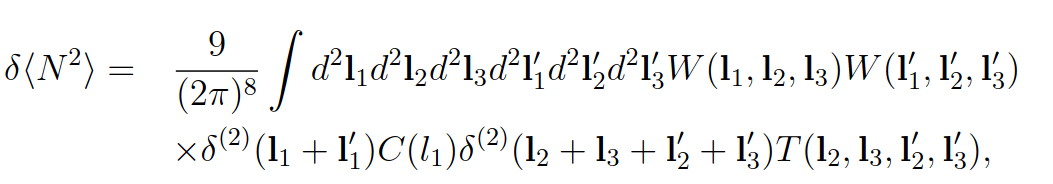

In [22]:
def compute_trispectrum_single(c_ell_TT, c_ell_phi, l1, l2, l3, l4):
    l13 = l1 + l3
    l14 = l1 + l4

    l1_mag = int(round(np.sqrt(np.dot(l1, l1))))
    l2_mag = int(round(np.sqrt(np.dot(l2, l2))))
    l13_mag = int(round(np.sqrt(np.dot(l13, l13))))
    l14_mag = int(round(np.sqrt(np.dot(l14, l14))))

    # flat sky approx -> C_l^\delta\delta / (|l|^2) = c_l^\phi
    T = np.dot(l13, l1) * np.dot(l13, l2) * c_ell_phi[l13_mag]
    T += np.dot(l14, l1) * np.dot(l14, l2) * c_ell_phi[l14_mag]
    return c_ell_TT[l1_mag] * c_ell_TT[l2_mag] * T


def compute_trispectrum(c_ell_TT, c_ell_phi, l1, l2, l3, l4):
    r"""
    T = C_l1^TT C_l2^TT [ ((l1+l3)dot l1 (l1+l3) dot l2) / (|l1+l3|^2)) C_l13^\delta\delta + ((l1+l4) dot l1 (l1+l4) dot l2) / (|l1+l4|^2)) C_l14^\delta\delta ] + permutations
    """
    lmax = np.shape(c_ell)[0] - 1
    for i in [l1, l2, l3, l4]:
        for j in [l1, l2, l3, l4]:
            if np.array_equal(i, j):
                if not 2 <= int(round(np.sqrt((i).dot(i)))) <= LMAX:
                    return 0.0
            elif not 2 <= int(round(np.sqrt((i + j).dot(i + j)))) <= lmax:
                return 0.0

    trispectrum = (
        compute_trispectrum_single(c_ell_TT, c_ell_phi, l1, l2, l3, l4)
        + compute_trispectrum_single(c_ell_TT, c_ell_phi, l1, l3, l4, l2)
        + compute_trispectrum_single(c_ell_TT, c_ell_phi, l1, l4, l2, l3)
        + compute_trispectrum_single(c_ell_TT, c_ell_phi, l2, l3, l4, l1)
        + compute_trispectrum_single(c_ell_TT, c_ell_phi, l2, l4, l3, l1)
        + compute_trispectrum_single(c_ell_TT, c_ell_phi, l3, l4, l1, l2)
    )

    return trispectrum


In [23]:
def tri_single(c_ell, c_ell_phi, l1, l2, l3, l4):
    """Calculate a single trispectrum configuration."""
    l13 = l1 + l3
    l13_mag = int(round(np.sqrt(l13.dot(l13))))
    l3_mag = int(round(np.sqrt(l3.dot(l3))))
    l4_mag = int(round(np.sqrt(l4.dot(l4))))

    l13_3 = np.dot(l13, l3)
    l24_4 = np.dot(l2 + l4, l4)
    return c_ell_phi[l13_mag] * c_ell[l3_mag] * c_ell[l4_mag] * l13_3 * l24_4


def tri(c_ell, c_ell_phi, l1, l2, l3, l4):
    lmax = np.shape(c_ell)[0] - 1
    for i in [l1, l2, l3, l4]:
        for j in [l1, l2, l3, l4]:
            if np.array_equal(i, j):
                if not 2 <= int(round(np.sqrt((i).dot(i)))) <= LMAX:
                    return 0.0
            elif not 2 <= int(round(np.sqrt((i + j).dot(i + j)))) <= lmax:
                return 0.0

    value = 0.0
    value += tri_single(c_ell, c_ell_phi, l1, l2, l3, l4)
    value += tri_single(c_ell, c_ell_phi, l1, l2, l4, l3)
    value += tri_single(c_ell, c_ell_phi, l1, l3, l2, l4)
    value += tri_single(c_ell, c_ell_phi, l1, l3, l4, l2)
    value += tri_single(c_ell, c_ell_phi, l1, l4, l2, l3)
    value += tri_single(c_ell, c_ell_phi, l1, l4, l3, l2)
    value += tri_single(c_ell, c_ell_phi, l2, l1, l3, l4)
    value += tri_single(c_ell, c_ell_phi, l2, l1, l4, l3)
    value += tri_single(c_ell, c_ell_phi, l2, l3, l1, l4)
    value += tri_single(c_ell, c_ell_phi, l2, l3, l4, l1)
    value += tri_single(c_ell, c_ell_phi, l2, l4, l1, l3)
    value += tri_single(c_ell, c_ell_phi, l2, l4, l3, l1)
    value += tri_single(c_ell, c_ell_phi, l3, l1, l2, l4)
    value += tri_single(c_ell, c_ell_phi, l3, l1, l4, l2)
    value += tri_single(c_ell, c_ell_phi, l3, l2, l1, l4)
    value += tri_single(c_ell, c_ell_phi, l3, l2, l4, l1)
    value += tri_single(c_ell, c_ell_phi, l3, l4, l1, l2)
    value += tri_single(c_ell, c_ell_phi, l3, l4, l2, l1)
    value += tri_single(c_ell, c_ell_phi, l4, l1, l2, l3)
    value += tri_single(c_ell, c_ell_phi, l4, l1, l3, l2)
    value += tri_single(c_ell, c_ell_phi, l4, l2, l1, l3)
    value += tri_single(c_ell, c_ell_phi, l4, l2, l3, l1)
    value += tri_single(c_ell, c_ell_phi, l4, l3, l1, l2)
    value += tri_single(c_ell, c_ell_phi, l4, l3, l2, l1)

    return value / 2.0


In [24]:
from mlpng import bispectrum


class DeltaN2Integrand:
    def __init__(self, lmax, c_ell, c_ell_lens, cl_phi):
        self.lmax = lmax
        self.c_ell = c_ell
        self.c_ell_lens = c_ell_lens
        self.cl_phi = cl_phi

    def __call__(self, x):
        l1 = np.array([x[0], x[1]])
        l2 = np.array([x[2], x[3]])
        lp2 = np.array([x[4], x[5]])

        # 4 deltas to handle
        # delta(l1+l2+33) from the first W
        l3 = -l1 - l2
        # delta(l1+l1')
        lp1 = -l1
        # delta(l2+l3+l2'+l3')
        lp3 = -l2 - l3 - lp2
        # delta(l1'+l2'+l3') from the second W
        # lp2 = -lp1 - lp3

        # get the magnitudes as ints so we get an index close
        l1_mag = int(round(np.sqrt(l1.dot(l1))))
        l2_mag = int(round(np.sqrt(l2.dot(l2))))
        l3_mag = int(round(np.sqrt(l3.dot(l3))))
        lp1_mag = int(round(np.sqrt(lp1.dot(lp1))))
        lp2_mag = int(round(np.sqrt(lp2.dot(lp2))))
        lp3_mag = int(round(np.sqrt(lp3.dot(lp3))))

        # maybe try without the lp limits?
        for xmag in [l1_mag, l2_mag, l3_mag, lp1_mag, lp2_mag, lp3_mag]:
            if not 2 <= xmag <= self.lmax:
                return 0.0

        W = compute_W(l1_mag, l2_mag, l3_mag)
        Wp = compute_W(lp1_mag, lp2_mag, lp3_mag)
        # T = -compute_trispectrum(self.c_ell, self.cl_phi, l2, l3, lp2, lp3)
        T = tri(self.c_ell, self.cl_phi, l2, l3, lp2, lp3)

        return W * Wp * self.c_ell[l1_mag] * T


def compute_delta_N2(lmax=LMAX, neval=5e5, nitn=(10, 10), summary=False):
    integrand = DeltaN2Integrand(
        lmax, c_ell, c_ell_lens, cl_phi
    )  # , alpha_l.T, beta_l.T, generator.radii
    # )
    bounds = [[-lmax, lmax], [-lmax, lmax]] * 3
    integ = vegas.Integrator(
        bounds, min_neval_batch=1024
    )  # [[-lmax, lmax], [-lmax, lmax]] * 3)

    integ(
        integrand,
        nitn=nitn[0],
        neval=neval,
        nproc=generator.slurm.n_cpus,
    )
    result = integ(
        integrand,
        nitn=nitn[1],
        neval=neval,
        nproc=generator.slurm.n_cpus,
    )

    if summary:
        print(result.summary(), flush=True)

    return 9 / (2 * np.pi) ** 8 * np.abs(result.mean) / np.pi


def compute_delta_N2_c(lmax=LMAX, neval=5e5, nitn=(10, 10), summary=False):
    integrand = bispectrum.DeltaN2Integrand(
        lmax, c_ell, c_ell_lens, cl_phi, alpha_l.T, beta_l.T, generator.radii
    )
    integ = vegas.Integrator([[-lmax, lmax], [-lmax, lmax]] * 3, min_neval_batch=512)

    integ(
        integrand,
        nitn=nitn[0],
        neval=neval,
        nproc=generator.slurm.n_cpus,
    )
    result = integ(
        integrand,
        nitn=nitn[1],
        neval=neval,
        nproc=generator.slurm.n_cpus,
    )

    if summary:
        print(result.summary(), flush=True)

    return 9 / (2 * np.pi) ** 8 * np.abs(result.mean) / np.pi

In [25]:
def random_unit_vector():
    """Generate a random 2D unit vector."""
    theta = np.random.uniform(0, 2 * np.pi)
    return np.array([np.cos(theta), np.sin(theta)])


def test_trispectrum_functions(c_ell, cl_phi, num_tests=1000, lmin=2, lmax=1000):
    results_tri = []
    results_compute = []
    ell_values = []

    # Ensure arrays are long enough
    assert len(c_ell) > lmax and len(cl_phi) > lmax, (
        "Power spectra must extend beyond lmax"
    )

    for i in range(num_tests):
        # Generate random ell magnitudes
        ell1 = np.random.randint(lmin, lmax)
        ell2 = np.random.randint(lmin, lmax)
        ell3 = np.random.randint(lmin, lmax)

        # Create random vectors with these magnitudes
        v1 = random_unit_vector() * ell1
        v2 = random_unit_vector() * ell2
        v3 = random_unit_vector() * ell3
        v4 = -(v1 + v2 + v3)
        ell4 = int(round(np.sqrt(v4.dot(v4))))

        tri_result = tri(c_ell, cl_phi, v1, v2, v3, v4)
        compute_result = -compute_trispectrum(c_ell, cl_phi, v1, v2, v3, v4)

        if tri_result == 0 or compute_result == 0:
            continue

        results_tri.append(tri_result)
        results_compute.append(compute_result)
        ell_values.append((ell1, ell2, ell3, ell4))

        # ratio = np.abs(tri_result / compute_result)
        # if 1 - 1e-4 > ratio or ratio > 1 + 1e-4:
        #     print("Large Discrepancy found...")
        #     print(f"Test {i + 1}:")
        #     print(
        #         f"  ℓ values: {v1} / {ell1}, {v2} / {ell2}, {v3} / {ell3}, {v4} / {ell4}"
        #     )
        #     print(f"  even parity: {(ell1 + ell2 + ell3 + ell4) % 2 == 0}")
        #     print(f"  tri result: {tri_result}")
        #     print(f"  compute_trispectrum result: {compute_result}")
        #     print(
        #         f"  ratio: {tri_result / compute_result if compute_result != 0 else 'inf'}"
        #     )
        #     print()

    # Plot comparison
    print(len(results_tri), "tests completed.")
    plt.figure(figsize=(10, 6))
    plt.semilogy(
        range(len(results_tri)),
        [
            np.abs(r1 / r2) if r2 != 0 else np.nan
            for r1, r2 in zip(results_tri, results_compute)
        ],
    )
    plt.axhline(y=1.0, color="r", linestyle="-")
    plt.xlabel("Test number")
    plt.ylabel("tri / compute_trispectrum ratio")
    plt.title("Comparison of trispectrum calculation methods")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return ell_values, results_tri, results_compute


# Run the test
# test_results = test_trispectrum_functions(c_ell, cl_phi, num_tests=10000)
# print(np.mean(test_results[1]), np.mean(test_results[2]))
# stop


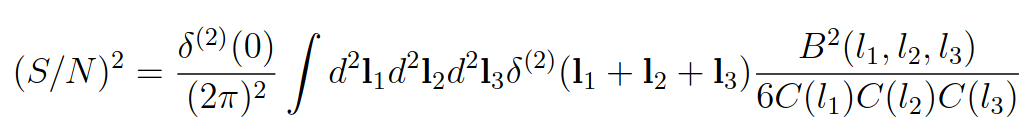

In [26]:
class SN2Integrand:
    def __init__(self, lmax, c_ell, alpha, beta, radii):
        self.lmax = lmax
        self.c_ell = c_ell
        self.alpha = alpha
        self.beta = beta
        self.radii = radii

    def __call__(self, x):
        l1 = np.array([x[0], x[1]])
        l2 = np.array([x[2], x[3]])
        l3 = -l1 - l2  # l3 is a vector

        # get the magnitudes as ints
        l1_mag = int(round(np.sqrt(l1.dot(l1))))
        l2_mag = int(round(np.sqrt(l2.dot(l2))))
        l3_mag = int(round(np.sqrt(l3.dot(l3))))

        for x in [l1_mag, l2_mag, l3_mag]:
            if not 2 <= x <= self.lmax:
                return 0.0

        B = compute_bispectrum(
            self.alpha, self.beta, l1_mag, l2_mag, l3_mag, self.radii
        )
        C6 = 6 * self.c_ell[l1_mag] * self.c_ell[l2_mag] * self.c_ell[l3_mag]
        return B**2 / C6


def compute_SN2(c_ell, lmax=LMAX, neval=1e5, summary=False):
    integrand = SN2Integrand(lmax, c_ell, alpha_l.T, beta_l.T, generator.radii)
    integ = vegas.Integrator([[-lmax, lmax], [-lmax, lmax]] * 2)

    integ(
        integrand,
        nitn=10,
        neval=neval // 10,
        nproc=generator.slurm.n_cpus,
    )
    result = integ(
        integrand,
        nitn=10,
        neval=neval,
        nproc=generator.slurm.n_cpus,
    )

    if summary:
        print(result.summary(), flush=True)

    # delta^(2)(0) = f_sky / pi, f_sky = 1
    return result.mean / np.pi / (2 * np.pi) ** 2

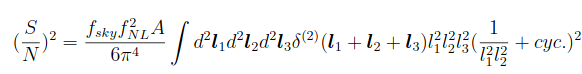

In [27]:
class SN2NTIntegrand:
    def __init__(self, lmax, c_ell, alpha, beta, radii):
        self.lmax = lmax
        self.c_ell = c_ell
        self.alpha = alpha
        self.beta = beta
        self.radii = radii

    def __call__(self, x):
        l1 = np.array([x[0], x[1]])
        l2 = np.array([x[2], x[3]])
        l3 = -l1 - l2

        # get the magnitudes as ints
        l1_mag = int(round(np.sqrt(l1.dot(l1))))
        l2_mag = int(round(np.sqrt(l2.dot(l2))))
        l3_mag = int(round(np.sqrt(l3.dot(l3))))

        for x in [l1_mag, l2_mag, l3_mag]:
            if not 2 <= x <= self.lmax:
                return 0.0

        inner = (
            1 / (l1_mag**2 * l2_mag**2)
            + 1 / (l1_mag**2 * l3_mag**2)
            + 1 / (l2_mag**2 * l3_mag**2)
        )
        return l1_mag**2 * l2_mag**2 * l3_mag**2 * inner**2


def compute_SN2_nt(
    c_ell,
    lmax=LMAX,
    neval=1e5,
    summary=False,
):
    integrand = SN2NTIntegrand(lmax, c_ell, alpha_l.T, beta_l.T, generator.radii)
    integ = vegas.Integrator([[-lmax, lmax], [-lmax, lmax]] * 2)

    integ(
        integrand,
        nitn=10,
        neval=neval // 10,
        nproc=generator.slurm.n_cpus,
    )
    result = integ(
        integrand,
        nitn=10,
        neval=neval,
        nproc=generator.slurm.n_cpus,
    )

    if summary:
        print(result.summary(), flush=True)

    As = generator.cosmo_params["As"]
    return As * result.mean / (6 * np.pi**4)


In [28]:
# sn2_ni = []
# sn2s = []
# sn2nts = []
# ells = np.arange(12, 1100, 100)
# As = generator.cosmo_params["As"]

# for lmax in tqdm(ells, desc="SN2 loop", total=len(ells)):
#     sn2_ni.append(4 / (np.pi**2) * As * lmax**2 * np.log(lmax / 2))
#     sn2 = compute_SN2(c_ell, lmax, summary=False)
#     sn2nt = compute_SN2_nt(c_ell, lmax, summary=False)
#     sn2s.append(sn2)
#     sn2nts.append(sn2nt)

# fig, ax = plt.subplots()
# ax.semilogy(ells, np.sqrt(sn2_ni), label="SN2 Non-integral")
# ax.semilogy(ells, np.sqrt(sn2s), label="SN2")
# ax.semilogy(ells, np.sqrt(sn2nts), label="SN2 NT")
# ax.set_ylabel(r"$(\frac{S}{N})$")
# ax.set_xlabel(r"$\ell_{\text{max}}$")
# ax.legend()
# ax.set_yticks([1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 5e-6])
# ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())
# ax.set_yscale("log")
# ax.set_xscale("log")
# ax.set_xticks([1, 10, 100, 1000])
# ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
# ax.xaxis.set_minor_locator(
#     plt.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=100)
# )
# ax.tick_params(axis="x", which="minor", length=4)
# ax.tick_params(axis="x", which="major", length=7)
# ax.grid(which="major", linestyle="-", linewidth=0.8, alpha=0.7)
# ax.grid(which="minor", linestyle=":", linewidth=0.5, alpha=0.5)
# plt.tight_layout()
# plt.show()

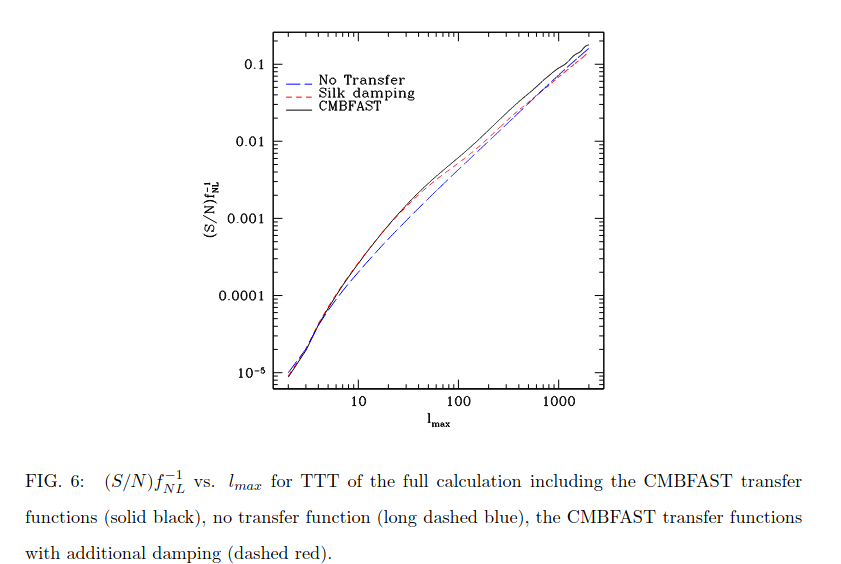

In [29]:
# print("Computing S...")
# s_avg = compute_S(summary=True)


In [30]:
# print("Computing N2...")
# N2_avg = compute_N2(c_ell, summary=True)

In [31]:
# print("Computing N2_lens...")
# N2_lens_avg = compute_N2(c_ell_lens, summary=True)


Computing delta_N2 with nevals=5000.0 and nint=(5, 10)...
itn   integral        wgt average     chi2/dof        Q
-------------------------------------------------------
  1   457(96)         457(96)             0.00     1.00
  2   265(85)         350(64)             2.26     0.13
  3   280(82)         324(50)             1.36     0.26
  4   347(77)         331(42)             0.93     0.43
  5   5.2(1.2)e+02    352(40)             1.24     0.29
  6   388(72)         360(35)             1.03     0.40
  7   461(81)         376(32)             1.08     0.37
  8   515(88)         392(30)             1.24     0.28
  9   8.5(4.4)e+02    394(30)             1.22     0.28
 10   415(82)         397(28)             1.09     0.37

0.00046802600030479365
Computation time: 2.85 seconds

Computing delta_N2 with nevals=10000.0 and nint=(5, 10)...
itn   integral        wgt average     chi2/dof        Q
-------------------------------------------------------
  1   513(96)         513(96)             0

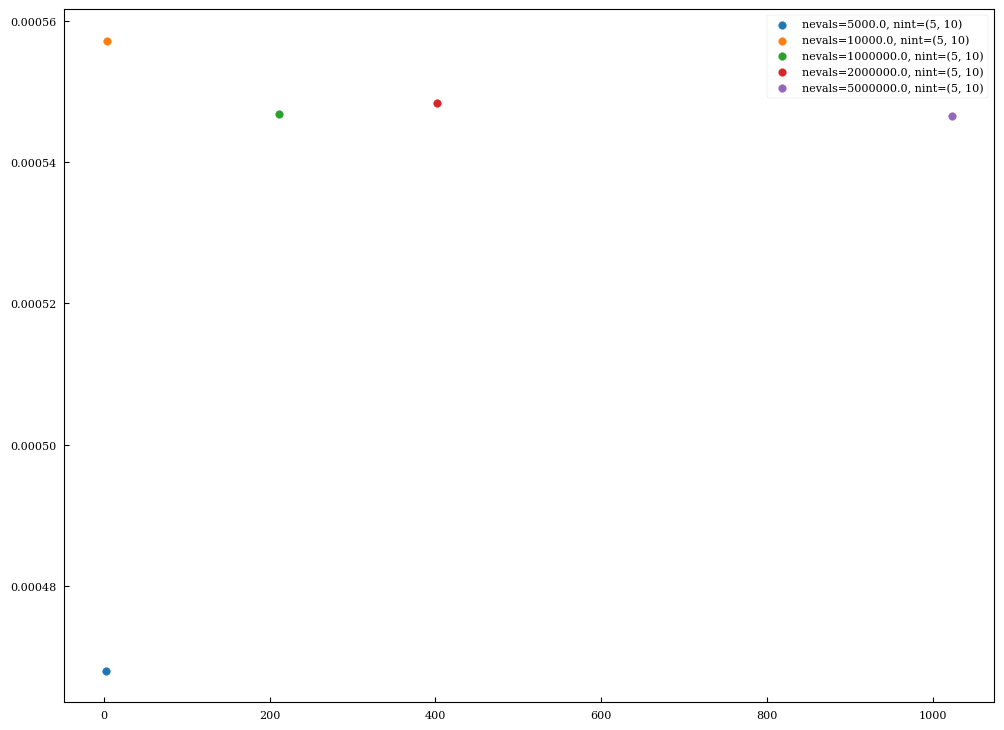

In [32]:
import time

evals = [5e3, 1e4, 1e6, 2e6, 5e6]
ints = [(5, 10)]  # , (5, 5), (4, 6)]
deltas = []
times = []
legends = []

for nevals in evals:
    for nint in ints:
        print(f"Computing delta_N2 with {nevals=} and {nint=}...")
        start_time = time.time()
        delta_N2 = compute_delta_N2(neval=nevals, nitn=nint, summary=True)
        end_time = time.time()
        deltas.append(delta_N2)
        times.append(end_time - start_time)
        legends.append(f"{nevals=}, {nint=}")
        print(delta_N2)
        print(f"Computation time: {end_time - start_time:.2f} seconds")
        print(flush=True)

for i in range(len(times)):
    plt.scatter(times[i], deltas[i], label=legends[i])
plt.legend()
plt.show()

In [ ]:
import time

evals = [1e6, 2e6, 3e6, 5e6]
ints = [(10, 10), (5, 5), (5, 10)]
deltas = []
times = []
legends = []

for nevals in evals:
    for nint in ints:
        print(f"Computing delta_N2 with {nevals=} and {nint=}...")
        start_time = time.time()
        delta_N2 = compute_delta_N2(neval=nevals, nitn=nint, summary=True)
        end_time = time.time()
        deltas.append(delta_N2)
        times.append(end_time - start_time)
        legends.append(f"{nevals=}, {nint=}")
        print(delta_N2)
        print(f"Computation time: {end_time - start_time:.2f} seconds")
        print(flush=True)

for i in range(len(times)):
    plt.scatter(times[i], deltas[i], label=legends[i])
plt.legend()
plt.show()


Computing delta_N2 with nevals=1000000.0 and nint=(10, 10)...
itn   integral        wgt average     chi2/dof        Q
-------------------------------------------------------
  1   475.5(5.4)      475.5(5.4)          0.00     1.00
  2   452(14)         472.4(5.0)          2.55     0.11
  3   456.3(4.8)      463.9(3.5)          3.99     0.02
  4   455.3(4.7)      460.9(2.8)          3.38     0.02
  5   472.9(5.1)      463.6(2.4)          3.60     0.01
  6   464.8(5.4)      463.8(2.2)          2.89     0.01
  7   466.3(5.0)      464.3(2.0)          2.44     0.02
  8   460.3(4.9)      463.7(1.9)          2.17     0.03
  9   463.7(4.9)      463.7(1.8)          1.90     0.06
 10   471.4(5.1)      464.5(1.7)          1.91     0.05

0.0005478131494601697
Computation time: 282.22 seconds

Computing delta_N2 with nevals=1000000.0 and nint=(5, 5)...
itn   integral        wgt average     chi2/dof        Q
-------------------------------------------------------
  1   473.0(9.8)      473.0(9.8)     

In [ ]:
# import time

# evals = [5e3, 1e4, 5e4, 5e5, 1e6, 2e6, 5e6, 1e7]
# ints = [(1, 1)]  # , (5, 5), (4, 6)]
# deltas = []
# times = []
# legends = []

# for nevals in evals:
#     for nint in ints:
#         print(f"Computing delta_N2 with {nevals=} and {nint=}...")
#         start_time = time.time()
#         delta_N2 = compute_delta_N2_c(neval=nevals, nitn=nint, summary=False)
#         end_time = time.time()
#         deltas.append(delta_N2)
#         times.append(end_time - start_time)
#         legends.append(f"{nevals=}, {nint=}")
#         print(delta_N2)
#         print(f"Computation time: {end_time - start_time:.2f} seconds")
#         print(flush=True)

# for i in range(len(times)):
#     plt.scatter(times[i], deltas[i], label=legends[i])
# plt.legend()
# plt.show()


In [ ]:
SN_0 = s_avg / np.sqrt(N2_avg)
SN_lens = s_avg / np.sqrt(N2_lens_avg + delta_N2)
SN_lens_neg = s_avg / np.sqrt(N2_lens_avg - delta_N2)

print(f"l_max: {LMAX}")
print(f"Average S: {s_avg}")
print(f"Average N^2 (unlensed): {N2_avg}")
print(f"Average N^2 (lensed): {N2_lens_avg}")
print(f"delta<N²> = {delta_N2}")
print(f"S/N (unlensed): {SN_0}")
print(f"S/N (lensed): {SN_lens}")
print(f"ratio: {SN_lens / SN_0}")
print(f"neg ratio: {SN_lens_neg / SN_0}")

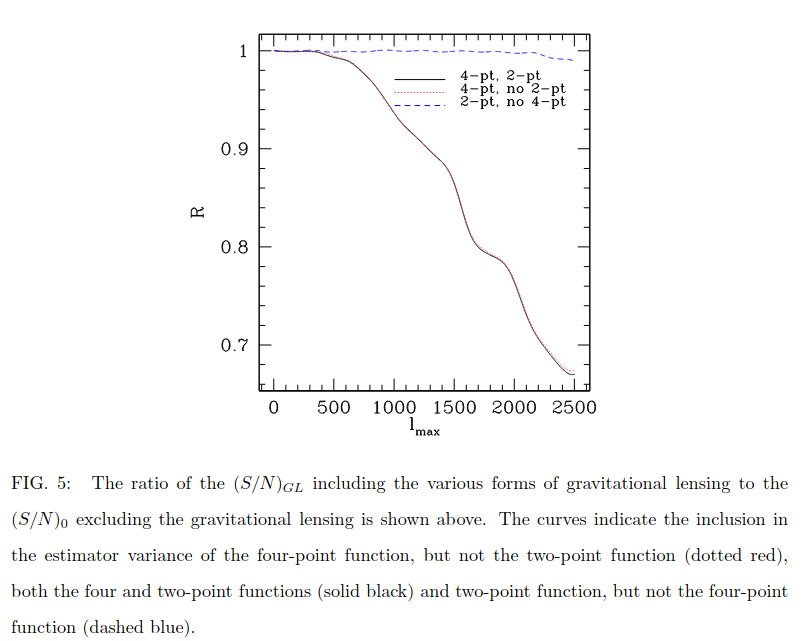

Make the plot, can take a while

In [ ]:
# rs = []
# rs_total = []
# ss = []
# n20s = []
# n2ls = []
# deltas = []
# s_ratio = []
# valid_ls = []

# ls = np.concatenate((np.arange(2, LMAX, 100), [LMAX]))
# for lmax in tqdm(ls, "data loop", len(ls)):
#     s_avg = compute_S(lmax)
#     N2_0 = compute_N2(c_ell, lmax)
#     N2_lens = compute_N2(c_ell_lens, lmax)
#     delta_N2 = compute_delta_N2(lmax)

#     sn_0 = s_avg / np.sqrt(N2_0)
#     sn_lens = s_avg / np.sqrt(N2_lens)
#     sn_delta_lens = s_avg / np.sqrt(N2_lens + delta_N2)

#     rs.append(sn_lens / sn_0)
#     rs_total.append(sn_delta_lens / sn_0)
#     ss.append(s_avg)
#     n20s.append(N2_0)
#     n2ls.append(N2_lens)
#     deltas.append(delta_N2)
#     valid_ls.append(lmax)

In [ ]:
# for label, x in [
#     ["<S>", ss],
#     ["<$N^2$>", n20s],
#     ["<$N^2_{lens}$>", n2ls],
#     [r"|$\delta<N^2>$|", np.abs(deltas)],
# ]:
#     # plt.figure()
#     plt.semilogy(valid_ls, x, label=label)
# plt.xlabel("lmax")
# plt.legend()
# plt.show()

In [ ]:
# plt.plot(valid_ls, rs, "--", color="blue")
# plt.plot(valid_ls, rs_total)
# plt.ylim(0.66, 1.02)
# plt.xlim(0.1, 2600)
# plt.ylabel("R")
# plt.xlabel(r"$\ell_{max}$")
# plt.title(r"$(S/N)_{GL} / (S/N)_{0}$")
# ax = plt.gca()
# ax.tick_params(which="both", top=True, right=True)
# plt.grid()
# plt.tight_layout()
# ax.set_yticks(np.arange(0.7, 1.02, 0.1))
# ax.set_xticks(np.arange(0, 2501, 500))
# ax.set_yticks(np.arange(0.66, 1.02, 0.02), minor=True)
# ax.set_xticks(np.arange(0, 2601, 100), minor=True)
# plt.show()